# Torchvision Guide for Beginners

Welcome to this comprehensive guide on `torchvision`. This library is part of the PyTorch project and consists of popular datasets, model architectures, and common image transformations for computer vision.

## Table of Contents
1. [Introduction](#1.-Introduction)
2. [Working with Datasets](#2.-Working-with-Datasets)
3. [Image Transformations](#3.-Image-Transformations)
4. [Using Pre-trained Models](#4.-Using-Pre-trained-Models)
5. [Utilities](#5.-Utilities)
6. [IO (Input/Output)](#6.-IO-(Input/Output))
7. [Functional Transforms](#7.-Functional-Transformations)
8. [Torchvision Ops](#8.-Torchvision-Ops)

## 1. Introduction

First, let's import the necessary libraries. We will need `torch`, `torchvision`, and some helper libraries like `matplotlib` for visualization.

In [2]:
import torch
import torch.nn as nn

In [3]:
import torchvision

print(f"Torch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")

Torch version: 2.4.1+cu121
Torchvision version: 0.19.1+cu121


In [4]:
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torchvision.models as models
import matplotlib.pyplot as plt
import numpy as np

## 2. Working with Datasets

`torchvision.datasets` provides easy access to many standard datasets like MNIST, CIFAR10, ImageNet, etc. These datasets inherit from `torch.utils.data.Dataset` and can be used directly with `torch.utils.data.DataLoader`.

In [16]:
# Define a simple transform to convert images to tensors
transform = transforms.Compose([
    transforms.ToTensor(),
])

# Download and load the CIFAR10 training set
cifar_train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)

print(f"Number of training samples: {len(cifar_train_dataset)}")
print(f"Classes: {cifar_train_dataset.classes}")

# Access a single sample
cifar_image, cifar_label = cifar_train_dataset[0]
print(f"Image shape: {cifar_image.shape}") # (C, H, W)
print(f"Label index: {cifar_label}")

Files already downloaded and verified
Number of training samples: 50000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Image shape: torch.Size([3, 32, 32])
Label index: 6


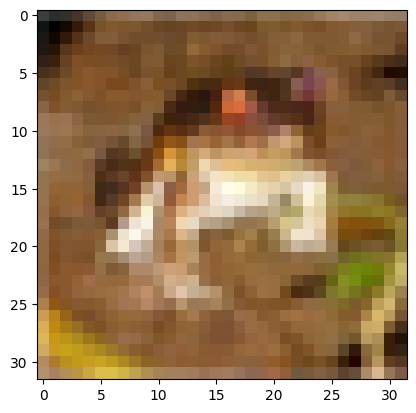

In [17]:
plt.imshow(cifar_train_dataset[0][0].permute(1, 2, 0))

In [20]:
# Define a simple transform to convert images to tensors
transform = transforms.Compose([
    transforms.ToTensor(),
])

# Download and load the FashionMNIST training set
fashion_mnist_train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)

print(f"Number of training samples: {len(fashion_mnist_train_dataset)}")
print(f"Classes: {fashion_mnist_train_dataset.classes}")

# Access a single sample
fashion_mnist_image, fashion_mnist_label = fashion_mnist_train_dataset[0]
print(f"Image shape: {fashion_mnist_image.shape}") # (C, H, W)
print(f"Label index: {fashion_mnist_label}")

Number of training samples: 60000
Classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
Image shape: torch.Size([1, 28, 28])
Label index: 9


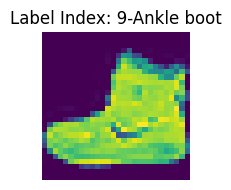

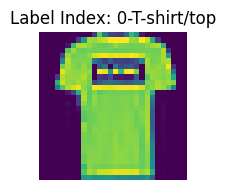

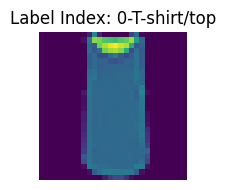

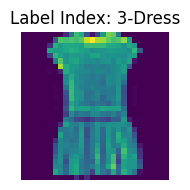

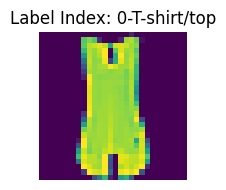

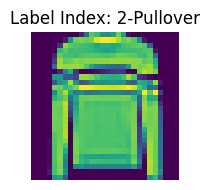

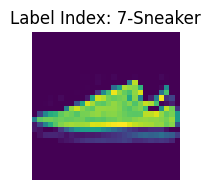

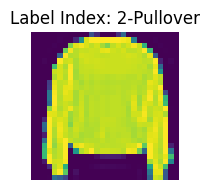

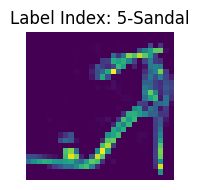

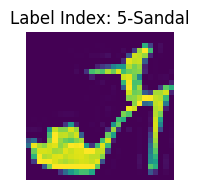

In [41]:
# for i in range(10):
#     plt.figure(figsize=(2, 2))
#     plt.imshow(fashion_mnist_train_dataset[i][0].permute(1, 2, 0))
#     plt.title(fashion_mnist_train_dataset[i][1])
#     plt.xlabel(fashion_mnist_train_dataset.classes[i])
#     plt.show()

for i in range(10):
    plt.figure(figsize=(2, 2))
    fm_img, fm_label = fashion_mnist_train_dataset[i]
    plt.imshow(fm_img.squeeze())
    plt.title(f"Label Index: {fm_label}-{fashion_mnist_train_dataset.classes[fm_label]}")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

## 3. Image Transformations

`torchvision.transforms` contains common image transformations. They can be chained together using `transforms.Compose`.

Common transforms:
- `Resize(size)`: Resize the image.
- `CenterCrop(size)`: Crops the image at the center.
- `ToTensor()`: Converts a PIL Image or numpy.ndarray (H x W x C) to tensor (C x H x W) in range [0.0, 1.0].
- `Normalize(mean, std)`: Normalize a tensor image with mean and standard deviation.
- `RandomHorizontalFlip()`: Horizontally flip the given image randomly with a given probability.

In [6]:
# augmentation pipeline
aug_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    
    # Normalize with ImageNet mean and std
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Let's apply this to a sample image from our dataset (we need to get the PIL image first, so we reload without ToTensor)
raw_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=None)
sample_img, _ = raw_dataset[0]

# Apply transforms
transformed_img = aug_transform(sample_img)
print(f"Original size: {sample_img.size}")
print(f"Transformed shape: {transformed_img.shape}")

Files already downloaded and verified
Original size: (32, 32)
Transformed shape: torch.Size([3, 224, 224])


## 4. Using Pre-trained Models

`torchvision.models` provides pre-trained models for various tasks like classification, detection, segmentation, etc. This is very useful for Transfer Learning.

In [7]:
# Load a pre-trained ResNet18 model
# weights='DEFAULT' loads the best available weights (usually ImageNet)
resnet18 = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Set model to evaluation mode
resnet18.eval()

# Inspect the model architecture (printing first few layers)
print(list(resnet18.children())[:3])

# Example inference
# We need a batch dimension, so we unsqueeze the transformed image
input_batch = transformed_img.unsqueeze(0)

with torch.no_grad():
    output = resnet18(input_batch)

print(f"Output shape: {output.shape}") # (Batch_Size, Num_Classes)
probabilities = torch.nn.functional.softmax(output[0], dim=0)
print(f"Top probability: {probabilities.max().item():.4f}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\Onepoint/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:07<00:00, 6.37MB/s]

[Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False), BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True), ReLU(inplace=True)]
Output shape: torch.Size([1, 1000])
Top probability: 0.1610


## 5. Utilities

`torchvision.utils` contains useful tools, such as `make_grid` for visualizing a grid of images and `draw_bounding_boxes` for object detection visualization.

Batch of images:


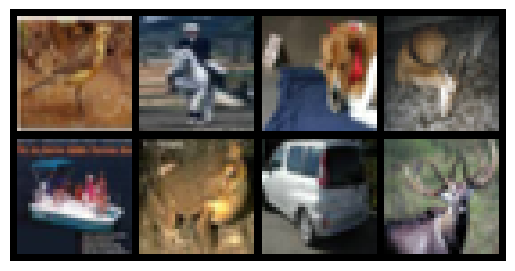

In [8]:
from torchvision.utils import make_grid

# Create a DataLoader to get a batch of images
dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=8, shuffle=True)
images, labels = next(iter(dataloader))

# Create a grid of images
grid_img = make_grid(images, nrow=4, padding=2)

# Helper function to show the image
def show(img):
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')
    plt.show()

print("Batch of images:")
show(grid_img)

Image with bounding box:


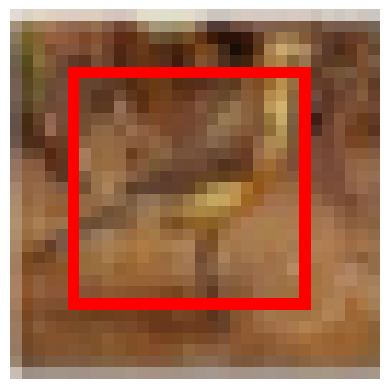

In [10]:
from torchvision.utils import draw_bounding_boxes

# Example: Draw a bounding box on the first image of the batch
# Bounding boxes are expected in (xmin, ymin, xmax, ymax) format
# Since CIFAR images are small (32x32), we'll make up a box
bbox = torch.tensor([[5, 5, 25, 25]]) # One box
img_uint8 = (images[0] * 255).to(torch.uint8) # draw_bounding_boxes expects uint8

img_with_box = draw_bounding_boxes(img_uint8, bbox, colors="red", width=1)
print("Image with bounding box:")
show(img_with_box)

## 6. IO (Input/Output)

`torchvision.io` allows you to read and write images and videos efficiently. It supports various formats.

In [11]:
from torchvision.io import read_image, write_jpeg
import os

# Let's save one of our CIFAR images to disk first so we can read it back
temp_img_path = "temp_cifar.jpg"
write_jpeg(img_uint8, temp_img_path)

# Now read it back using read_image
# This returns a tensor in (C, H, W) format, uint8
read_tensor = read_image(temp_img_path)

print(f"Read tensor shape: {read_tensor.shape}")
print(f"Read tensor dtype: {read_tensor.dtype}")

# Clean up
if os.path.exists(temp_img_path):
    os.remove(temp_img_path)

Read tensor shape: torch.Size([3, 32, 32])
Read tensor dtype: torch.uint8


## 7. Functional Transformations

While `transforms` provides classes for building pipelines, `torchvision.transforms.functional` (often imported as `F`) provides stateless functions. This gives you fine-grained control, which is useful for complex augmentations (e.g., applying the exact same random rotation to both an image and its segmentation mask).

Rotated image by 45 degrees:


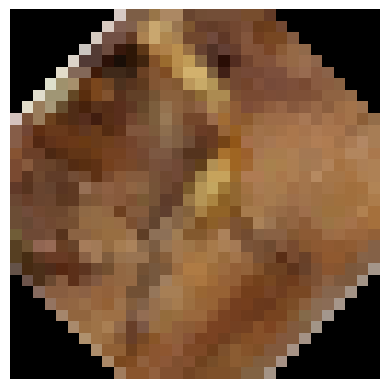

Brightened image:


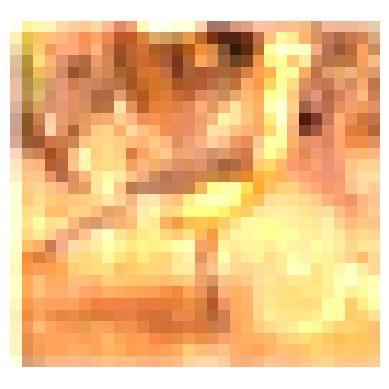

In [12]:
import torchvision.transforms.functional as F

# Rotate an image by a specific angle
angle = 45
rotated_img = F.rotate(images[0], angle)

print(f"Rotated image by {angle} degrees:")
show(rotated_img)

# Adjust brightness
bright_img = F.adjust_brightness(images[0], brightness_factor=2.0)
print("Brightened image:")
show(bright_img)

## 8. Torchvision Ops

`torchvision.ops` implements specialized operators for computer vision that might not be available in core PyTorch, such as Non-Maximum Suppression (NMS), RoIAlign, etc. These are crucial for object detection models.

In [13]:
from torchvision.ops import nms

# Example: Non-Maximum Suppression
# Suppose we have 3 predicted boxes for the same object
boxes = torch.tensor([
    [10, 10, 50, 50],  # Box 1
    [12, 12, 52, 52],  # Box 2 (very similar to Box 1)
    [100, 100, 150, 150] # Box 3 (different location)
], dtype=torch.float32)

scores = torch.tensor([0.9, 0.85, 0.7]) # Confidence scores
iou_threshold = 0.5

# Apply NMS
keep_indices = nms(boxes, scores, iou_threshold)

print(f"Indices to keep: {keep_indices}")
# It should keep index 0 (highest score among overlapping) and index 2 (non-overlapping)

Indices to keep: tensor([0, 2])


## Conclusion

This notebook covered the essentials of `torchvision`:
1.  **Datasets**: Loading standard data.
2.  **Transforms**: Preprocessing and augmenting data.
3.  **Models**: Using pre-trained networks.
4.  **Utils**: Visualizing data.
5.  **IO**: Reading/writing files.
6.  **Functional & Ops**: Advanced control and specialized operators.

Explore the [official documentation](https://pytorch.org/vision/stable/index.html) for more details!